# Statistical Tests
Notebook conducts a set of statistical tests on our method which decomposes the system into noise + trend to understand their performance

In [150]:
import sys
sys.path.append('../scripts')

from peak_tester import EmissionsPeakTest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.ar_model import AutoReg
from scipy.stats import jarque_bera
from scipy.stats import jarque_bera, probplot

Notebook tests for:
1) heteroskedacity (using the ARCH test)
2) normality (using the Jacques-Bera test)
3) presence of autocorrelation (Ljung-Box test)

# Testing heteroskedacity

Applies ARCH test for heteroskedacity (p-value > 0.05 indicates variance is constant)

In [2]:
import os, sys

class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w', encoding='utf-8')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

## Define set of methods we want to test and parameterise them

In [3]:
# find residuals for different methods (use normal as default for noise distribution, but this only affects noise generation, not the residuals themselves)
methods =[
        "linear",
        "linear_w_autocorrelation",
        "broken_trend",
        "hp",
        "hamilton",
        "spline",
        "lowess",
    ]

In [4]:


residuals_dict = {}
innovations_dict = {} # CF: I'm not sure if we need to do this for innovations, probably doesn't make sense, but including for now
emissions_tester = EmissionsPeakTest()
emissions_tester.load_historical_data(
    'gcb_hist_co2.csv', region='WLD', year_range = range(1970,2025))
with HiddenPrints():
    for method in methods:
        if method == 'lowess':
            emissions_tester.characterize_noise(method=method, noise_type = 't-dist',include_test_data=False, fraction=0.1)
        else:
            emissions_tester.characterize_noise(method=method, noise_type = 't-dist',include_test_data=False) 
        residuals_dict[method] = emissions_tester.residuals
        innovations_dict[method] = emissions_tester.autocorr_params['residuals']

    


Loaded historical data: 1970-2024
Data points: 55


# Testing heteroskedacity

Applies ARCH test for heteroskedacity (p-value > 0.05 indicates variance is constant)

In [5]:
# Test all methods for heteroskedasticity 
arch_df = pd.DataFrame([
    {
        'Method': method,
        'ARCH Test Statistic': het_arch(residuals_dict[method])[0],
        'p-value': het_arch(residuals_dict[method])[1]
    }
    for method in methods
])
print(arch_df)


                     Method  ARCH Test Statistic   p-value
0                    linear            34.396162  0.000158
1  linear_w_autocorrelation            16.302680  0.091289
2              broken_trend             7.854606  0.643036
3                        hp             7.493468  0.678180
4                  hamilton             3.330245  0.949752
5                    spline             6.887382  0.736032
6                    lowess             1.933784  0.996823


The linear approach fails to pass the ARCH test. All others do, though linear_w_autocorrelation is more borderline (failing at p = 0.1)

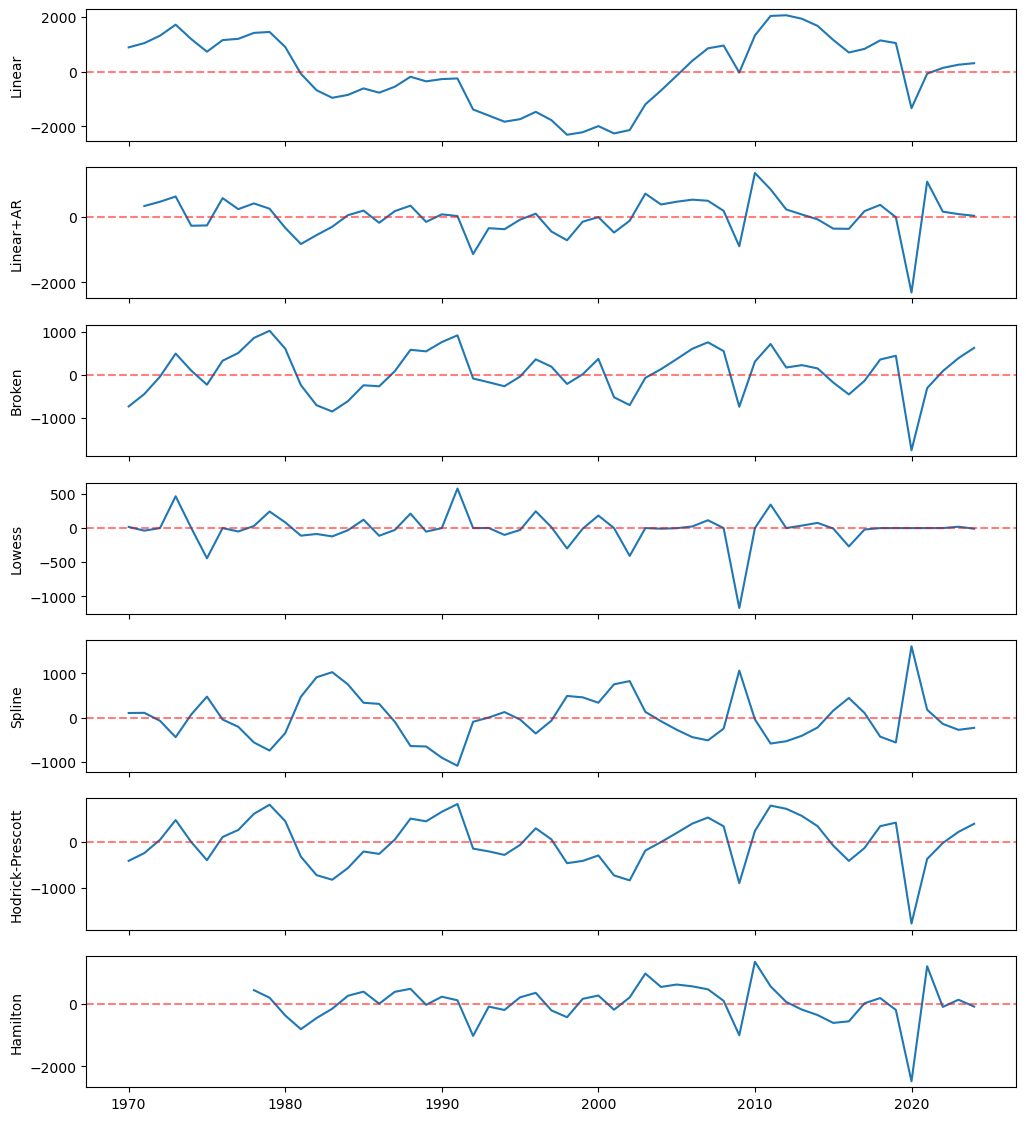

In [6]:
# Plotting residuals for all methods to visually inspect for patterns - shows that linear has a pattern
fig, axes = plt.subplots(7, 1, figsize=(12, 14), sharex=True)
for i, (method, resids) in enumerate([('Linear', residuals_dict['linear']), 
                                       ('Linear+AR', residuals_dict['linear_w_autocorrelation']),
                                       ('Broken', residuals_dict['broken_trend']),
                                       ('Lowess', residuals_dict['lowess']),
                                       ('Spline', residuals_dict['spline']),
                                       ('Hodrick-Prescott', residuals_dict['hp']),
                                       ('Hamilton', residuals_dict['hamilton'])]):
    axes[i].plot(resids)
    axes[i].set_ylabel(method)
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5)

# Testing autocorrelation 
Code applies Ljung-box test to test for autocorrelation (p>0.05 across lags means white noise)


### Focus on broken trend

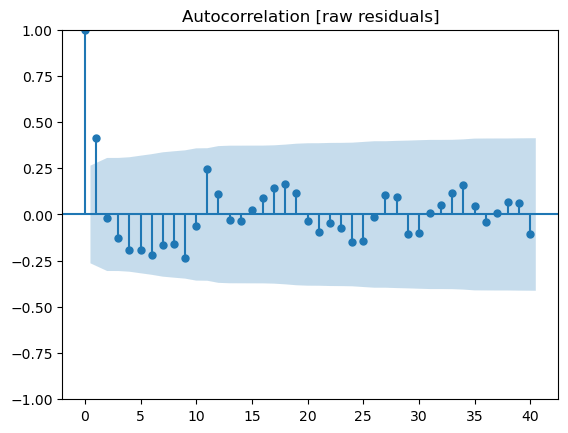

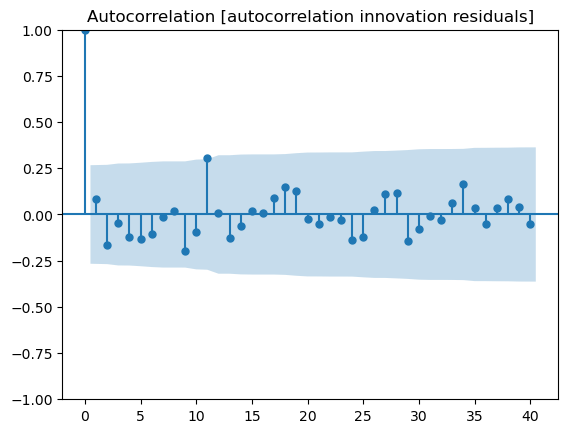

Ljung-Box test: Residuals

      lb_stat  lb_pvalue
1    9.871521   0.001679
2    9.887636   0.007127
3   10.875812   0.012417
4   13.204385   0.010319
5   15.582262   0.008144
6   18.646996   0.004803
7   20.406166   0.004756
8   22.077981   0.004773
9   25.782071   0.002218
10  26.059608   0.003661
11  30.289074   0.001427
12  31.157053   0.001864
13  31.218977   0.003132
14  31.320269   0.004999
15  31.368105   0.007840
16  32.027229   0.009918
17  33.702633   0.009170
18  35.977688   0.007103
19  37.121234   0.007662
20  37.232073   0.010974

Ljung-Box test: Innovations

      lb_stat  lb_pvalue
1    0.422337   0.515773
2    2.008448   0.366329
3    2.120371   0.547803
4    2.995842   0.558521
5    4.079523   0.538024
6    4.802206   0.569421
7    4.817075   0.682275
8    4.834840   0.775074
9    7.458427   0.589503
10   8.101171   0.618955
11  14.671443   0.198038
12  14.674313   0.259732
13  15.881429   0.255592
14  16.187019   0.302087
15  16.207989   0.368365
16  16.214833   0.

In [7]:
# Test broken trend residuals for autocorrelation

method = 'broken_trend'

residuals = residuals_dict[method]

# 1. ACF plot
plot_acf(residuals, lags=40, title='Autocorrelation [raw residuals]')
plt.show()

# 2. ACF plot of innovations from peak_tester analysis
innovations = innovations_dict[method]
plot_acf(innovations, lags=40, title='Autocorrelation [autocorrelation innovation residuals]')
plt.show()

# 3. Run Ljung-Box test on residuals
lb = acorr_ljungbox(residuals, lags=20, return_df=True)

# 4. Run Ljung-Box test on innovations
lb_innovations = acorr_ljungbox(innovations, lags=20, return_df=True)

print('Ljung-Box test: Residuals\n')
print(lb)

print('\nLjung-Box test: Innovations\n')
print(lb_innovations)   

Results suggest there is autocorrelation in residuals and not in innovations (as expected)

In [8]:
# Fit AR(1) and test residuals

ar1_model = AutoReg(residuals, lags=1).fit()

# Get the new residuals after fitting AR(1)
ar1_residuals = ar1_model.resid

print(f"AR(1) coefficient: {ar1_model.params[1]:.4f}")

residuals_to_test = ar1_residuals

# Run Ljung-Box test
lb = acorr_ljungbox(residuals_to_test, lags=20, return_df=True)

# Run ARCH test
arch = het_arch(residuals_to_test, nlags=10)

print("Ljung-Box Test:")
print(lb)
print(f"\nARCH Test p-value: {arch[1]}")

AR(1) coefficient: 0.4217
Ljung-Box Test:
      lb_stat  lb_pvalue
1    0.422337   0.515773
2    2.008448   0.366329
3    2.120371   0.547803
4    2.995842   0.558521
5    4.079523   0.538024
6    4.802206   0.569421
7    4.817075   0.682275
8    4.834840   0.775074
9    7.458427   0.589503
10   8.101171   0.618955
11  14.671443   0.198038
12  14.674313   0.259732
13  15.881429   0.255592
14  16.187019   0.302087
15  16.207989   0.368365
16  16.214833   0.438070
17  16.858071   0.464021
18  18.729784   0.408638
19  20.148770   0.385677
20  20.207390   0.445026

ARCH Test p-value: 0.9266158533989904


LB test shows autocorrelation removed with AR1, and ARCH test is passed

In [9]:
# Check properties of other autocorrelation structures (e.g. AR(2), AR(3))
for p in [1, 2, 3]:
    model = AutoReg(residuals, lags=p).fit()
    print(f"AR({p}) - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

AR(1) - AIC: 824.14, BIC: 830.11
AR(2) - AIC: 808.99, BIC: 816.87
AR(3) - AIC: 796.79, BIC: 806.55


AIC/BIC suggests that AR3 is best, but this seems strange

In [10]:
# Fit AR(2) and AR(3)
ar2_model = AutoReg(residuals, lags=2).fit()
ar3_model = AutoReg(residuals, lags=3).fit()

ar2_residuals = ar2_model.resid
ar3_residuals = ar3_model.resid

# Test both
print("AR(2) Ljung-Box:")
print(acorr_ljungbox(ar2_residuals, lags=20, return_df=True))

print("\nAR(3) Ljung-Box:")
print(acorr_ljungbox(ar3_residuals, lags=20, return_df=True))

AR(2) Ljung-Box:
      lb_stat  lb_pvalue
1    0.004636   0.945717
2    0.032414   0.983924
3    0.099341   0.991916
4    1.391096   0.845741
5    2.631771   0.756532
6    3.811815   0.702125
7    4.196540   0.756882
8    4.212484   0.837461
9    5.916672   0.748228
10   6.948970   0.730254
11  12.528246   0.325273
12  12.749935   0.387475
13  13.276131   0.426716
14  13.317836   0.501664
15  13.369099   0.573812
16  13.373776   0.645257
17  14.271394   0.647807
18  15.633338   0.618120
19  17.147765   0.579858
20  17.148127   0.643335

AR(3) Ljung-Box:
      lb_stat  lb_pvalue
1    0.001354   0.970646
2    0.088039   0.956935
3    0.260390   0.967297
4    1.296205   0.862019
5    2.615177   0.759058
6    3.911333   0.688674
7    4.257702   0.749663
8    4.283723   0.830661
9    6.256252   0.714023
10   7.383935   0.688770
11  12.896947   0.300114
12  13.114323   0.360786
13  13.743466   0.392155
14  13.760273   0.467719
15  13.847392   0.537133
16  13.853679   0.609614
17  14.654772  

In [11]:
print(ar2_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   55
Model:                     AutoReg(2)   Log Likelihood                -400.496
Method:               Conditional MLE   S.D. of innovations            462.933
Date:                Fri, 13 Mar 2026   AIC                            808.991
Time:                        15:35:37   BIC                            816.872
Sample:                             2   HQIC                           812.022
                                   55                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.0644     64.218      1.029      0.304     -59.801     191.930
y.L1           0.5069      0.134      3.769      0.000       0.243       0.770
y.L2          -0.2246      0.132     -1.700      0.0

In [12]:
print(ar3_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   55
Model:                     AutoReg(3)   Log Likelihood                -393.394
Method:               Conditional MLE   S.D. of innovations            467.005
Date:                Fri, 13 Mar 2026   AIC                            796.789
Time:                        15:35:37   BIC                            806.545
Sample:                             3   HQIC                           800.529
                                   55                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.3782     65.828      1.039      0.299     -60.643     197.399
y.L1           0.4978      0.140      3.568      0.000       0.224       0.771
y.L2          -0.2081      0.153     -1.362      0.1

Results show that p value of AR2 is only significant for AR2, not AR3. AR1 is always significant and Ljunb-box test shows it leaves white noise, so AR1 seems most robust choise

### Explore linear_w_autoccorelation approach

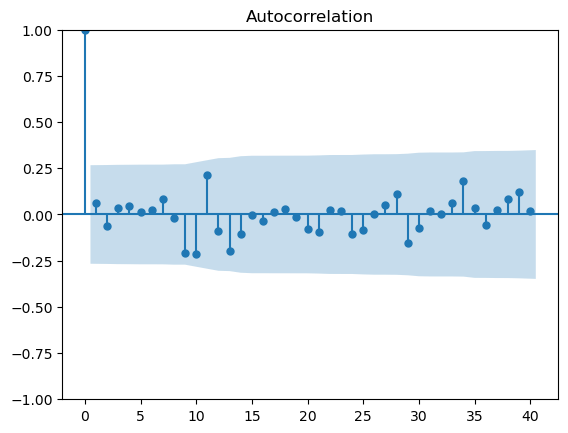

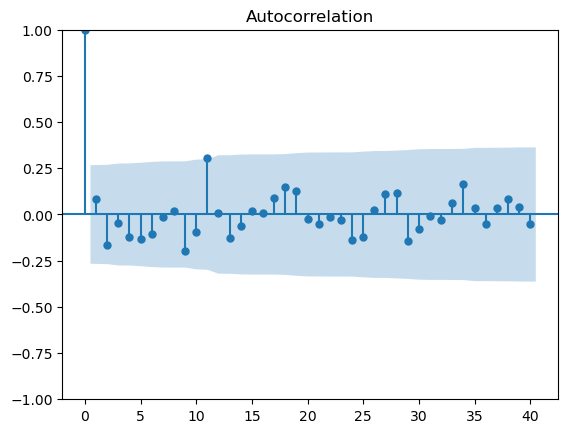

    lb_stat  lb_pvalue
1  0.204820   0.650858
2  0.428271   0.807239
3  0.506270   0.917512
4  0.635543   0.959033
5  0.647292   0.985736
    lb_stat  lb_pvalue
1  0.422337   0.515773
2  2.008448   0.366329
3  2.120371   0.547803
4  2.995842   0.558521
5  4.079523   0.538024

ARCH Test p-value: 0.09128948179744727


In [13]:
# Test linear_w_autocorrelation method

residuals = residuals_dict['linear_w_autocorrelation']
innovations = innovations_dict['linear_w_autocorrelation']

# 1. ACF plot
plot_acf(residuals, lags=40)
plt.show()

# 2. ACF plot of innovations from peak_tester analysis
innovations = innovations_dict[method]
plot_acf(innovations, lags=40)

# 3. Run Ljung-Box test on residuals
lb = acorr_ljungbox(residuals, lags=20, return_df=True)

# 4. Run Ljung-Box test on innovations
lb_innovations = acorr_ljungbox(innovations, lags=20, return_df=True)

# 5. Run ARCH test on residuals
arch = het_arch(residuals, nlags=10)

plt.show()
print(lb.head())
print(lb_innovations.head())  
print(f"\nARCH Test p-value: {arch[1]}")

As expected, the residuals from linear_w_autocorrelation are white noise. 

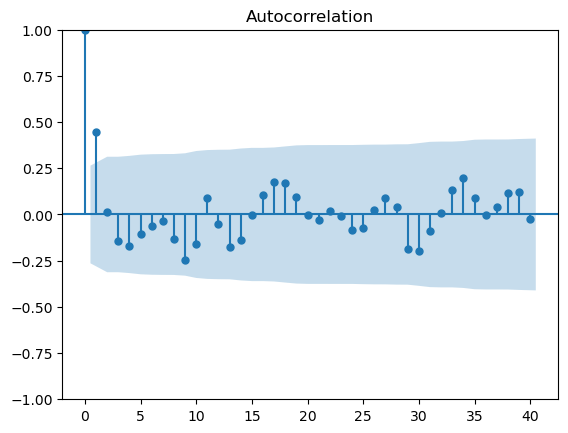

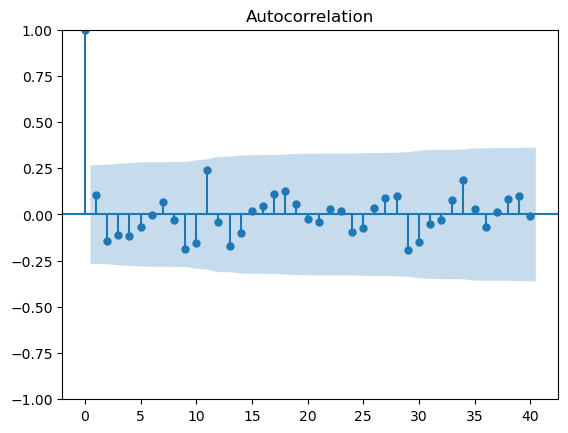

     lb_stat  lb_pvalue
1  11.543469   0.000680
2  11.554599   0.003097
3  12.823714   0.005034
4  14.654552   0.005474
5  15.383127   0.008845
    lb_stat  lb_pvalue
1  0.621411   0.430523
2  1.784867   0.409658
3  2.548049   0.466670
4  3.399654   0.493299
5  3.672824   0.597413


In [151]:
# test lowess residuals for AC 

method = 'lowess'
residuals = residuals_dict[method]
innovations = innovations_dict[method]

# 1. ACF plot
plot_acf(residuals, lags=40)
plt.show()

# 2. ACF plot of innovations from peak_tester analysis
innovations = innovations_dict[method]
plot_acf(innovations, lags=40)

# 3. Run Ljung-Box test on residuals
lb = acorr_ljungbox(residuals, lags=20, return_df=True)

# 4. Run Ljung-Box test on innovations
lb_innovations = acorr_ljungbox(innovations, lags=20, return_df=True)

plt.show()
print(lb.head())
print(lb_innovations.head())   


## Testing lowess
Lowess residuals have autocorrelation, but innovations do not

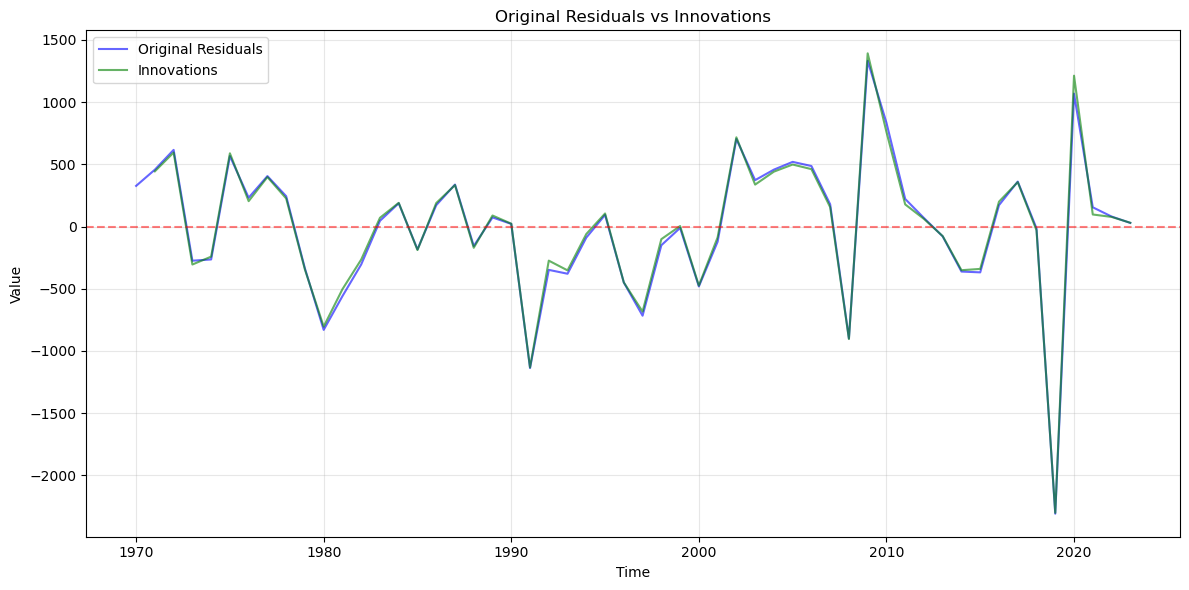

In [15]:

plt.figure(figsize=(12, 6))

years = np.arange(1970, 2024)  # Assuming residuals start from 1971 due to differencing for AR(1)
plt.plot(years, residuals_dict['linear_w_autocorrelation'], label='Original Residuals', color='blue', alpha=0.6, linewidth=1.5)
plt.plot(years[1:], innovations_dict['linear_w_autocorrelation'], label='Innovations', color='green', alpha=0.6, linewidth=1.5)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Residuals vs Innovations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Why are these plots of residuals and innovations slightly different for linear_w_autocorrelation? Shouldn't there be no AR adjustment done?

# Testing normality

In [16]:
# First test residuals and innovations when all years are included
# Test normality for all  methods
normality_df = pd.DataFrame()

for method in methods:
    # Get residuals and AR innovations for each method
    jb_stat_res, jb_pvalue_res = jarque_bera(residuals_dict[method])
    jb_stat_innov, jb_pvalue_innov = jarque_bera(innovations_dict[method])
    normality_df = pd.concat([normality_df, pd.DataFrame({
        'Method': [method],
        'JB Statistic (residuals)': [jb_stat_res],
        'p-value (residuals)': [jb_pvalue_res],
        'Normal? (residuals)': ['Yes' if jb_pvalue_res  >= 0.05 else 'No'],
        'JB Statistic (innovations)': [jb_stat_innov],
        'p-value (innovations)': [jb_pvalue_innov],
        'Normal? (innovations)': ['Yes' if jb_pvalue_innov  >= 0.05 else 'No']
    })], ignore_index=True)

normality_df

,Method,JB Statistic (residuals),p-value (residuals),Normal? (residuals),JB Statistic (innovations),p-value (innovations),Normal? (innovations)
0,linear,3.308748,1.912117e-01,Yes,36.299955,1.310886e-08,No
1,linear_w_autocorrelation,45.158763,1.562785e-10,No,45.188879,1.539428e-10,No
2,broken_trend,6.241876,4.411576e-02,No,58.859824,1.654823e-13,No
3,hp,7.088175,2.889497e-02,No,70.995256,3.833328e-16,No
4,hamilton,52.320732,4.352086e-12,No,49.223926,2.047200e-11,No
5,spline,4.020710,1.339411e-01,Yes,42.747165,5.218806e-10,No
6,lowess,312.099465,1.692241e-68,No,292.814538,2.606940e-64,No


In [17]:
# Then try with covid year (2020) removed - removing 1991 doesn't affect the results much, but removing 2020 does.
# Find residuals for different methods, ignoring outlier years

residuals_dict_no2020 = {}
innovations_dict_no2020 = {} 

with HiddenPrints():
    for method in methods:
        if method == 'lowess':
            emissions_tester.characterize_noise(method=method, noise_type = 't-dist',
                                                include_test_data=False, fraction=0.1,
                                                ignore_years=[2020])
        else:
            emissions_tester.characterize_noise(method=method, noise_type = 't-dist',include_test_data=False,
                                                ignore_years=[2020]) 
        residuals_dict_no2020[method] = emissions_tester.residuals
        innovations_dict_no2020[method] = emissions_tester.autocorr_params['residuals']

    

Text(0.5, 1.0, 'Residuals for global CO2 emissions under\nlinear w/ autocorrelation, 2020 excluded')

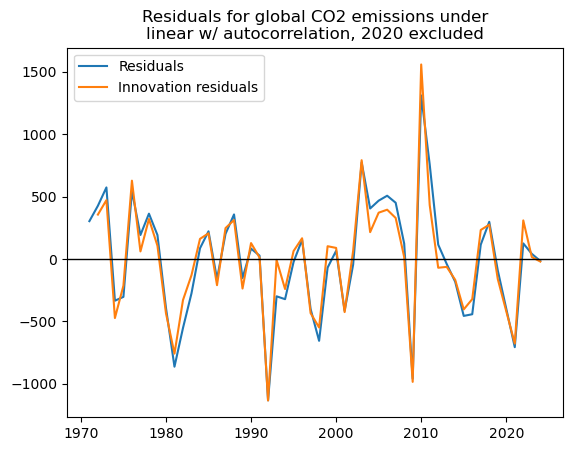

In [18]:
residuals_dict_no2020['linear_w_autocorrelation'].plot()
plt.plot(residuals_dict_no2020['linear_w_autocorrelation'].index[1:],innovations_dict_no2020['linear_w_autocorrelation'])
ax = plt.gca()
ax.axhline(y=0,color='k',lw=1)
ax.legend(['Residuals','Innovation residuals'])
ax.set_title('Residuals for global CO2 emissions under\nlinear w/ autocorrelation, 2020 excluded')

In [21]:
jarque_bera(pd.Series(
    index=residuals_dict_no2020['linear_w_autocorrelation'].index[1:],
    data=innovations_dict_no2020['linear_w_autocorrelation']
))

SignificanceResult(statistic=np.float64(10.577680218078266), pvalue=np.float64(0.0050476115446132985))

In [22]:
jarque_bera(innovations_dict_no2020['linear_w_autocorrelation'])

SignificanceResult(statistic=np.float64(10.577680218078266), pvalue=np.float64(0.0050476115446132985))

In [23]:
jarque_bera(residuals_dict_no2020['linear_w_autocorrelation'].loc[1972:])

SignificanceResult(statistic=np.float64(0.5748958255575927), pvalue=np.float64(0.7501756403178755))

In [24]:
# Test normality for all  methods (no covid)
normality_df = pd.DataFrame()

for method in methods:
    # Get residuals and AR innovations for each method
    jb_stat_res, jb_pvalue_res = jarque_bera(residuals_dict_no2020[method])
    jb_stat_innov, jb_pvalue_innov = jarque_bera(innovations_dict_no2020[method])
    normality_df = pd.concat([normality_df, pd.DataFrame({
        'Method': [method],
        'JB Statistic (residuals)': [jb_stat_res],
        'p-value (residuals)': [jb_pvalue_res],
        'Normal? (residuals)': ['Yes' if jb_pvalue_res  >= 0.05 else 'No'],
        'JB Statistic (innovations)': [jb_stat_innov],
        'p-value (innovations)': [jb_pvalue_innov],
        'Normal? (innovations)': ['Yes' if jb_pvalue_innov  >= 0.05 else 'No']
    })], ignore_index=True)

normality_df

,Method,JB Statistic (residuals),p-value (residuals),Normal? (residuals),JB Statistic (innovations),p-value (innovations),Normal? (innovations)
0,linear,3.244933,1.974112e-01,Yes,0.941673,6.244797e-01,Yes
1,linear_w_autocorrelation,0.619552,7.336114e-01,Yes,10.577680,5.047612e-03,No
2,broken_trend,1.477013,4.778270e-01,Yes,2.947760,2.290351e-01,Yes
3,hp,1.544897,4.618808e-01,Yes,2.399399,3.012847e-01,Yes
4,hamilton,9.166934,1.021940e-02,No,10.382533,5.564954e-03,No
5,spline,1.046314,5.926466e-01,Yes,4.803841,9.054387e-02,Yes
6,lowess,275.064279,1.864450e-60,No,257.407925,1.272270e-56,No


In [25]:
# Test normality for all  methods (no covid)
normality_df = pd.DataFrame()

for method in methods:
    # Get residuals and AR innovations for each method
    jb_stat_res, jb_pvalue_res = jarque_bera(residuals_dict_no2020[method])
    jb_stat_innov, jb_pvalue_innov = jarque_bera(innovations_dict_no2020[method])
    normality_df = pd.concat([normality_df, pd.DataFrame({
        'Method': [method],
        'JB Statistic (residuals)': [jb_stat_res],
        'p-value (residuals)': [jb_pvalue_res],
        'Normal? (residuals)': ['Yes' if jb_pvalue_res  >= 0.05 else 'No'],
        'JB Statistic (innovations)': [jb_stat_innov],
        'p-value (innovations)': [jb_pvalue_innov],
        'Normal? (innovations)': ['Yes' if jb_pvalue_innov  >= 0.05 else 'No']
    })], ignore_index=True)

normality_df

,Method,JB Statistic (residuals),p-value (residuals),Normal? (residuals),JB Statistic (innovations),p-value (innovations),Normal? (innovations)
0,linear,3.244933,1.974112e-01,Yes,0.941673,6.244797e-01,Yes
1,linear_w_autocorrelation,0.619552,7.336114e-01,Yes,10.577680,5.047612e-03,No
2,broken_trend,1.477013,4.778270e-01,Yes,2.947760,2.290351e-01,Yes
3,hp,1.544897,4.618808e-01,Yes,2.399399,3.012847e-01,Yes
4,hamilton,9.166934,1.021940e-02,No,10.382533,5.564954e-03,No
5,spline,1.046314,5.926466e-01,Yes,4.803841,9.054387e-02,Yes
6,lowess,275.064279,1.864450e-60,No,257.407925,1.272270e-56,No


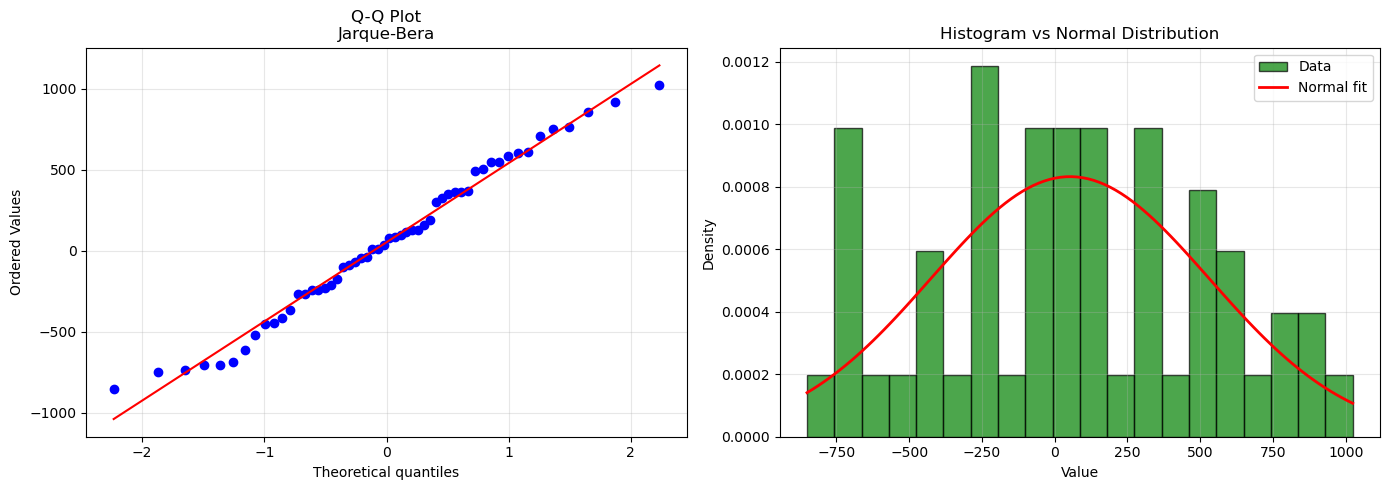

In [26]:
# # Plot for broken trend residuals
# jb_stat, jb_pvalue = jarque_bera(ar1_residuals)

# Create diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot
probplot(residuals_dict_no2020['broken_trend'], dist="norm", plot=axes[0])
axes[0].set_title(f'Q-Q Plot\nJarque-Bera')
axes[0].grid(True, alpha=0.3)
    
# Histogram with normal overlay
axes[1].hist(residuals_dict_no2020['broken_trend'], bins=20, density=True, alpha=0.7, 
             color='green', edgecolor='black', label='Data')

# Overlay normal distribution
from scipy.stats import norm
mu, sigma = residuals_dict_no2020['broken_trend'].mean(), residuals_dict_no2020['broken_trend'].std()
x = np.linspace(residuals_dict_no2020['broken_trend'].min(), residuals_dict_no2020['broken_trend'].max(), 100)
axes[1].plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal fit')

axes[1].set_title('Histogram vs Normal Distribution')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### Investigating linear and linear_w_autocorrelation methods further


In [27]:
# Check linear_w_autocorrelation AC results

emissions_tester.characterize_noise(method='linear_w_autocorrelation', noise_type = 't-dist',include_test_data=False,
                                                ignore_years=[2020]) 
emissions_tester.autocorr_params

using t-dist distribution to calculate noise
Fitted t-distribution to innovations: df = 4.4
Autocorrelation analysis:

  Lag-1 autocorr: 0.252
  Residual σ (post-autocorrelation): 441.0
  Has significant autocorr: True
  Likelihood of autocorr: 0.9411972060047805
Noise characterization complete:
  Method used: linear_w_autocorrelation


{'has_autocorr': np.True_,
 'phi': np.float64(0.2524012815518017),
 'residuals': array([  356.07252144,   472.0618946 ,  -473.07669906,  -213.21151274,
          627.98774944,    60.75962023,   320.80277627,   106.22909788,
         -434.14314551,  -758.64838153,  -329.41484888,  -129.70661374,
          161.39270546,   206.2205908 ,  -209.68995517,   247.63814428,
          312.46505866,  -236.66622013,   127.73149266,    12.02207255,
        -1134.10442465,    -7.03989211,  -240.59177768,    63.92861114,
          166.29187825,  -433.73322446,  -548.95250101,   102.54839697,
           88.99216485,  -425.28199184,    65.23945758,   792.06878136,
          215.45467868,   371.51882887,   395.27219328,   328.92819876,
           16.07833521,  -984.89110786,  1559.57316267,   432.77221587,
          -69.9670792 ,   -63.08003573,  -167.15050496,  -403.99736091,
         -321.71005103,   232.7972027 ,   275.25995986,  -160.10082638,
         -677.9357527 ,   309.37360359,    15.82201293, 

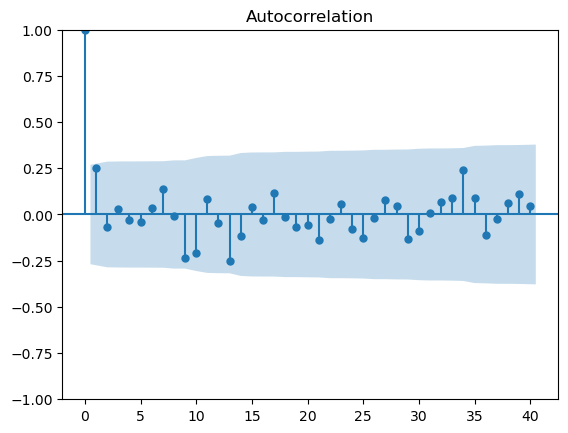

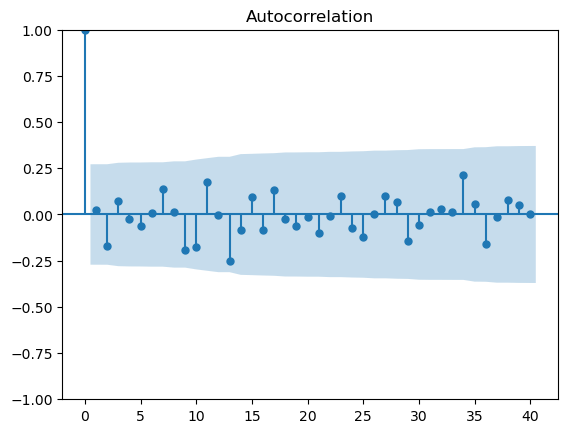

      lb_stat  lb_pvalue
1    3.570833   0.058803
2    3.840065   0.146602
3    3.891583   0.273412
4    3.948072   0.413079
5    4.039648   0.543722
6    4.109311   0.661886
7    5.304759   0.622826
8    5.309610   0.724030
9    8.900357   0.446523
10  11.867307   0.294035
11  12.355075   0.337554
12  12.506714   0.405889
13  17.172162   0.191553
14  18.199334   0.197852
15  18.323239   0.246053
16  18.389976   0.301560
17  19.465719   0.302464
18  19.482372   0.362702
19  19.871268   0.402362
20  20.165561   0.447617
      lb_stat  lb_pvalue
1    0.034738   0.852145
2    1.659707   0.436113
3    1.980722   0.576418
4    2.020399   0.732007
5    2.266392   0.811190
6    2.271762   0.893086
7    3.501289   0.835089
8    3.511232   0.898316
9    5.981507   0.741768
10   8.051968   0.623761
11  10.180383   0.514238
12  10.180697   0.600112
13  14.685446   0.327399
14  15.204323   0.364332
15  15.857762   0.391567
16  16.395640   0.425705
17  17.838711   0.399084
18  17.881257   0.463501


In [28]:
method = 'linear_w_autocorrelation'

residuals = residuals_dict_no2020[method]

# 1. ACF plot
plot_acf(residuals, lags=40)
plt.show()

# 2. ACF plot of innovations from peak_tester analysis
innovations = innovations_dict_no2020[method]
plot_acf(innovations, lags=40)

# 3. Run Ljung-Box test on residuals
lb = acorr_ljungbox(residuals, lags=20, return_df=True)

# 4. Run Ljung-Box test on innovations
lb_innovations = acorr_ljungbox(innovations, lags=20, return_df=True)

plt.show()
print(lb)
print(lb_innovations)   

In [29]:
# Let's look at the linear approach and which AC function is best
# Fit AR(1) and test residuals

residuals = residuals_dict_no2020['linear']
ar1_model = AutoReg(residuals, lags=1).fit()

# Get the new residuals after fitting AR(1)
ar1_residuals = ar1_model.resid

print(f"AR(1) coefficient: {ar1_model.params[1]:.4f}")

residuals_to_test = ar1_residuals

# Run Ljung-Box test
lb = acorr_ljungbox(residuals_to_test, lags=20, return_df=True)


print("Ljung-Box Test:")
print(lb)
print(f"\nARCH Test p-value: {arch[1]}")

AR(1) coefficient: 0.9233
Ljung-Box Test:
      lb_stat  lb_pvalue
1    3.390048   0.065591
2    3.595126   0.165702
3    3.689632   0.296987
4    3.695438   0.448790
5    3.695485   0.594036
6    3.900315   0.690164
7    5.272699   0.626723
8    5.281771   0.727079
9    8.296995   0.504516
10  11.350362   0.330881
11  12.582396   0.321493
12  12.645490   0.395326
13  16.855958   0.205973
14  18.083523   0.203003
15  18.138925   0.255432
16  18.247001   0.309633
17  18.763925   0.342250
18  18.777833   0.405623
19  19.031453   0.454820
20  19.419430   0.494732

ARCH Test p-value: 0.09128948179744727


Results show some AC for first 1-2 lags

In [30]:
# Check properties of other autocorrelation structures (e.g. AR(2), AR(3))
for p in [1, 2, 3]:
    model = AutoReg(residuals, lags=p).fit()
    print(f"AR({p}) - AIC: {model.aic:.2f}, BIC: {model.bic:.2f}")

AR(1) - AIC: 808.69, BIC: 814.60
AR(2) - AIC: 792.38, BIC: 800.19
AR(3) - AIC: 779.30, BIC: 788.96


In [31]:
# AIC/BIC suggests AR3 is best
# Fit AR(2) and AR(3)
ar2_model = AutoReg(residuals, lags=2).fit()
ar3_model = AutoReg(residuals, lags=3).fit()
print(ar1_model.summary())
print(ar2_model.summary())
print(ar3_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   54
Model:                     AutoReg(1)   Log Likelihood                -401.345
Method:               Conditional MLE   S.D. of innovations            470.413
Date:                Fri, 13 Mar 2026   AIC                            808.690
Time:                        15:35:38   BIC                            814.601
Sample:                             1   HQIC                           810.963
                                   54                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.6171     64.617     -0.211      0.833    -140.263     113.029
y.L1           0.9233      0.051     18.104      0.000       0.823       1.023
                                    Roots           

These results suggest AR2 is needed for the linear approach when the year 2020 is excluded (p values are significant for L1 and L2 in both AR2 and AR3). BUT a coefficient >1 (non-stationary) in AR1 followed by a negative coefficient in L2 is a warning sign that the lienar approach doesn't work well. (a negative coefficient in AR2 suggests an oscillating pattern).

In [32]:
# Now testing linear when 2020 is included 


residuals = residuals_dict['linear']
ar1_model = AutoReg(residuals, lags=1).fit()

# Get the new residuals after fitting AR(1)
ar1_residuals = ar1_model.resid

print(f"AR(1) coefficient: {ar1_model.params[1]:.4f}")

residuals_to_test = ar1_residuals

# Run Ljung-Box test
lb = acorr_ljungbox(residuals_to_test, lags=20, return_df=True)


print("Ljung-Box Test:")
print(lb.head())

AR(1) coefficient: 0.8912
Ljung-Box Test:
    lb_stat  lb_pvalue
1  0.243101   0.621975
2  0.417906   0.811433
3  0.535684   0.910985
4  0.681786   0.953556
5  0.718914   0.981915


In [33]:
# Fit AR(2) and AR(3)
ar2_model = AutoReg(residuals, lags=2).fit()
ar3_model = AutoReg(residuals, lags=3).fit()

ar2_residuals = ar2_model.resid
ar3_residuals = ar3_model.resid

print(ar2_model.summary())
print(ar3_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   55
Model:                     AutoReg(2)   Log Likelihood                -411.201
Method:               Conditional MLE   S.D. of innovations            566.554
Date:                Fri, 13 Mar 2026   AIC                            830.402
Time:                        15:35:38   BIC                            838.283
Sample:                             2   HQIC                           833.433
                                   55                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.6156     77.845     -0.201      0.841    -168.190     136.959
y.L1           0.9565      0.137      6.996      0.000       0.688       1.224
y.L2          -0.0757      0.136     -0.556      0.5

In [34]:
# now checking linear_w_autocorrelation when 2020 is excluded
residuals = residuals_dict_no2020['linear_w_autocorrelation']

ar1_model = AutoReg(residuals, lags=1).fit()
ar2_model = AutoReg(residuals, lags=2).fit()
ar3_model = AutoReg(residuals, lags=3).fit()

print (ar1_model.summary())
print (ar2_model.summary())
print (ar3_model.summary()  )

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   53
Model:                     AutoReg(1)   Log Likelihood                -390.419
Method:               Conditional MLE   S.D. of innovations            441.034
Date:                Fri, 13 Mar 2026   AIC                            786.838
Time:                        15:35:38   BIC                            792.692
Sample:                             1   HQIC                           789.082
                                   53                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.9139     61.160     -0.097      0.923    -125.786     113.958
y.L1           0.2524      0.134      1.890      0.059      -0.009       0.514
                                    Roots           

In [35]:
# Let's test the broken trend approach when 2020 is excluded
residuals = residuals_dict_no2020['broken_trend']

ar1_model = AutoReg(residuals, lags=1).fit()
ar2_model = AutoReg(residuals, lags=2).fit()
ar3_model = AutoReg(residuals, lags=3).fit()

print (ar1_model.summary())
print (ar2_model.summary())
print (ar3_model.summary()  )

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                   54
Model:                     AutoReg(1)   Log Likelihood                -390.960
Method:               Conditional MLE   S.D. of innovations            386.709
Date:                Fri, 13 Mar 2026   AIC                            787.921
Time:                        15:35:38   BIC                            793.832
Sample:                             1   HQIC                           790.194
                                   54                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.7856     53.376      0.783      0.434     -62.830     146.401
y.L1           0.5476      0.111      4.923      0.000       0.330       0.766
                                    Roots           

# T distributions

For broken trend, analysis suggests that when covid is excluded a normal distribution would be enough, but when covid is included a t distribution is better.

In [36]:
# Fit t distribution and examine degrees of freedom
from scipy import stats

# Fit t-distribution
df, loc, scale = stats.t.fit(innovations_dict_no2020['broken_trend'])

print(f"t-distribution parameters:")
print(f"  Degrees of freedom: {df:.2f}")
print(f"  Location: {loc:.4f}")
print(f"  Scale: {scale:.4f}")

if df > 30:
    print("\n→ df > 30: t-distribution is very close to normal")
    print("  Using t vs normal won't make much difference")
else:
    print(f"\n→ df = {df:.2f}: heavier tails than normal")
    print("  t-distribution is more appropriate")

t-distribution parameters:
  Degrees of freedom: 999.72
  Location: -3.5883
  Scale: 386.3909

→ df > 30: t-distribution is very close to normal
  Using t vs normal won't make much difference


In [37]:
# With 2020 included
# Fit t-distribution
df, loc, scale = stats.t.fit(innovations_dict['broken_trend'])

print(f"t-distribution parameters:")
print(f"  Degrees of freedom: {df:.2f}")
print(f"  Location: {loc:.4f}")
print(f"  Scale: {scale:.4f}")

if df > 30:
    print("\n→ df > 30: t-distribution is very close to normal")
    print("  Using t vs normal won't make much difference")
else:
    print(f"\n→ df = {df:.2f}: heavier tails than normal")
    print("  t-distribution is more appropriate")

t-distribution parameters:
  Degrees of freedom: 5.21
  Location: 60.7290
  Scale: 363.0053

→ df = 5.21: heavier tails than normal
  t-distribution is more appropriate


In [38]:
# Test across methods - excluding covid
dof_results = pd.DataFrame()
for method in methods:
    df, loc, scale = stats.t.fit(innovations_dict_no2020[method])
    df2, loc2, scale2 = stats.t.fit(innovations_dict[method])
    dof_results = pd.concat([dof_results, pd.DataFrame({
        'Method': [method],
        'Degrees of Freedom (no 2020)': [f"{df:.2f}"],
        'Degrees of Freedom (with 2020)': [f"{df2:.2f}"]
    })], ignore_index=True)

dof_results

,Method,Degrees of Freedom (no 2020),Degrees of Freedom (with 2020)
0,linear,7.40,3.57
1,linear_w_autocorrelation,4.43,3.16
2,broken_trend,999.72,5.21
3,hp,78.16,4.66
4,hamilton,4.17,2.88
5,spline,26.91,4.82
6,lowess,1.30,0.32


Including 2020, all methods would be better using a t-distribution (thicker tails). Excluding covid, broken trend and hp are effectively normal, but the others would still benefit from an t-test

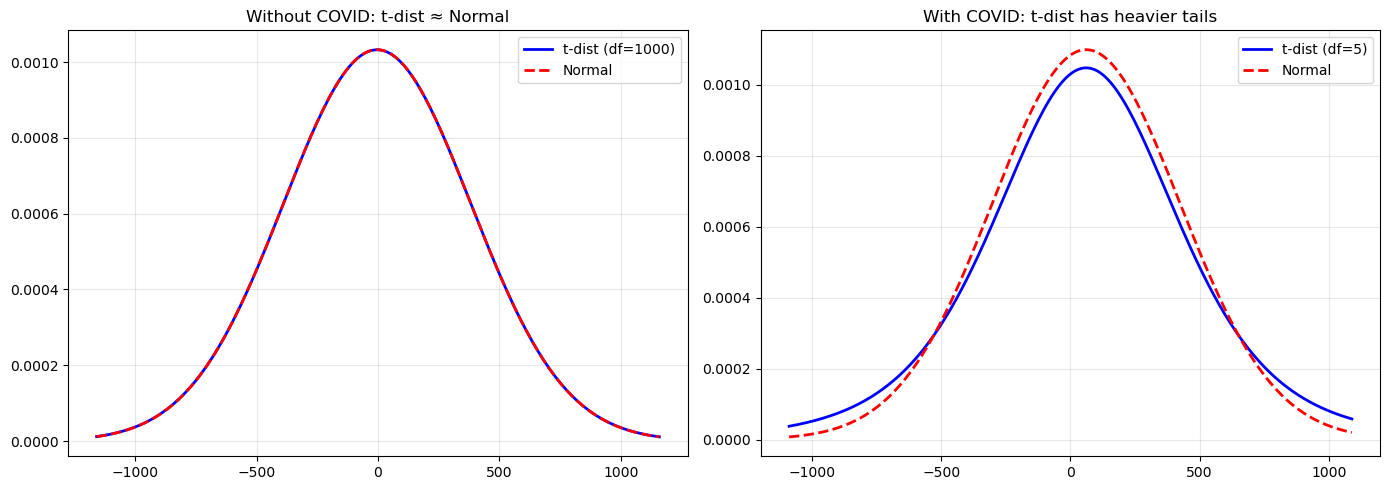

In [40]:
# Plot distributions
from scipy import stats

df_no_covid, loc_no_covid, scale_no_covid = stats.t.fit(innovations_dict_no2020['broken_trend'])
df_with_covid, loc_with_covid, scale_with_covid = stats.t.fit(innovations_dict['broken_trend'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without COVID
x = np.linspace(-3*scale_no_covid, 3*scale_no_covid, 200)
axes[0].plot(x, stats.t.pdf(x, df=df_no_covid, loc=loc_no_covid, scale=scale_no_covid),
             'b-', linewidth=2, label=f't-dist (df={df_no_covid:.0f})')
axes[0].plot(x, stats.norm.pdf(x, loc=loc_no_covid, scale=scale_no_covid),
             'r--', linewidth=2, label='Normal')
axes[0].set_title('Without COVID: t-dist ≈ Normal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# With COVID
x = np.linspace(-3*scale_with_covid, 3*scale_with_covid, 200)
axes[1].plot(x, stats.t.pdf(x, df=df_with_covid, loc=loc_with_covid, scale=scale_with_covid),
             'b-', linewidth=2, label=f't-dist (df={df_with_covid:.0f})')
axes[1].plot(x, stats.norm.pdf(x, loc=loc_with_covid, scale=scale_with_covid),
             'r--', linewidth=2, label='Normal')
axes[1].set_title('With COVID: t-dist has heavier tails')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()